# PHASE 3: Exploratory Data Analysis (EDA) & Initial Cleaning
**Traceability**
- Issue ID: #3 Exploratory Data Analysis

## 1. Objectives
- Load raw data.
- Analyze data properties.
- Perform initial cleaning (remove zero-variance features).
- Output the `cleaned_dataset.csv` for experimentation.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Column Definitions
INDEX_COLS = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
COL_NAMES = INDEX_COLS + SETTING_COLS + SENSOR_COLS

# Load Raw Data
def load_data(filename):
    return pd.read_csv(DATA_DIR / filename, sep=r'\s+', header=None, names=COL_NAMES)

df_train = load_data('train_FD001.txt')
df_test = load_data('test_FD001.txt')

# Load RUL for Train (Calculated) and Test (Provided)
def add_rul(df):
    # For train, RUL = max_cycle - current_cycle
    max_cycles = df.groupby('unit_number')['time_cycles'].max()
    df = df.merge(max_cycles.rename('max_cycle'), on='unit_number')
    df['RUL'] = df['max_cycle'] - df['time_cycles']
    return df.drop(columns=['max_cycle'])

df_train = add_rul(df_train)

# For test, we need RUL_FD001.txt for the *last* cycle, but for the experiment structure 
# we often just prep the test set features. The target RUL for test is usually for the end.
# However, to have a 'y_target' column in test set as per spec (Sec 12), we need ground truth.
# The provided RUL_FD001.txt is the RUL at the *last* time_cycle of the test file.
rul_test = pd.read_csv(DATA_DIR / 'RUL_FD001.txt', header=None, names=['RUL_end'])
rul_test['unit_number'] = range(1, len(rul_test) + 1)

# Merge RUL info into test. 
# Current RUL at time t = RUL_end + (max_cycle_in_test - t)
max_cycles_test = df_test.groupby('unit_number')['time_cycles'].max()
df_test = df_test.merge(max_cycles_test.rename('max_cycle'), on='unit_number')
df_test = df_test.merge(rul_test, on='unit_number')
df_test['RUL'] = df_test['RUL_end'] + df_test['max_cycle'] - df_test['time_cycles']
df_test = df_test.drop(columns=['max_cycle', 'RUL_end'])

print(f"✅ Raw data loaded. Train: {df_train.shape}, Test: {df_test.shape}")

### 2. Feature Relevance Analysis (Cleaning)
We remove features that are constant (zero variance) or have no correlation with degradation.

In [ ]:
# 1. Zero Variance Check
desc = df_train.describe().T
zero_variance_cols = desc[desc['std'] == 0].index.tolist()
print(f"🔍 Zero variance columns: {zero_variance_cols}")

# 2. Drop them
df_train_clean = df_train.drop(columns=zero_variance_cols)
df_test_clean = df_test.drop(columns=zero_variance_cols)

# 3. Low Correlation Check (Optional but recommended in spec)
# We check correlation of sensors with RUL in Training set
corr = df_train_clean.corr()['RUL'].abs().sort_values()
print("\n🔍 Correlation with RUL (Abs):")
print(corr)

# Define a threshold (e.g., 0.01) or just rely on the fact that constant cols are gone.
# The spec says "Removed features with no correlation". 
# Looking at the output, 'setting_3' might be constant or low variance.
# Let's stick to dropping the zero-variance ones identified above.

print(f"\n✅ Dropped {len(zero_variance_cols)} columns.")
print(f"New Train Shape: {df_train_clean.shape}")

# Save Cleaned Datasets
# Spec requires 'cleaned_dataset.csv'. We will save both train and test.
df_train_clean.to_csv(PROCESSED_DIR / 'cleaned_dataset.csv', index=False)
df_test_clean.to_csv(PROCESSED_DIR / 'cleaned_test_dataset.csv', index=False)
print(f"✅ Saved cleaned datasets to {PROCESSED_DIR}")

### 3.1 Diagnostic: Engine Lifetime Analysis
We need to know how long engines typically last to define "Early", "Mid", and "Late" life stages.

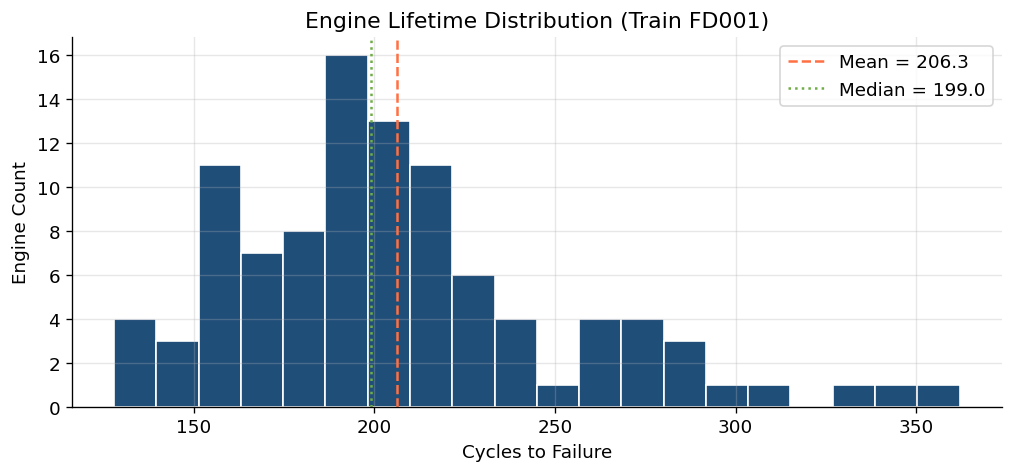

--- Engine Lifetime Stats ---
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64


In [7]:
def engine_lifetime_analysis(df):
    """Plot distribution of engine lifetimes."""
    max_cycles = df.groupby('unit_number')['time_cycles'].max()
    
    plt.figure(figsize=(10, 4))
    plt.hist(max_cycles, bins=20, color=COLORS[0], edgecolor='white')
    plt.axvline(max_cycles.mean(), color=COLORS[3], linestyle='--', label=f'Mean = {max_cycles.mean():.1f}')
    plt.axvline(max_cycles.median(), color=COLORS[2], linestyle=':', label=f'Median = {max_cycles.median():.1f}')
    plt.title('Engine Lifetime Distribution (Train FD001)')
    plt.xlabel('Cycles to Failure')
    plt.ylabel('Engine Count')
    plt.legend()
    plt.show()
    
    return max_cycles.describe()

lifetime_stats = engine_lifetime_analysis(df_train)
print("--- Engine Lifetime Stats ---")
print(lifetime_stats)

### 3.2 Diagnostic: Sensor Trends vs RUL
We calculate RUL (Max Cycle - Current Cycle) and plot sensor values. We look for monotonic trends (upward or downward) as RUL decreases.

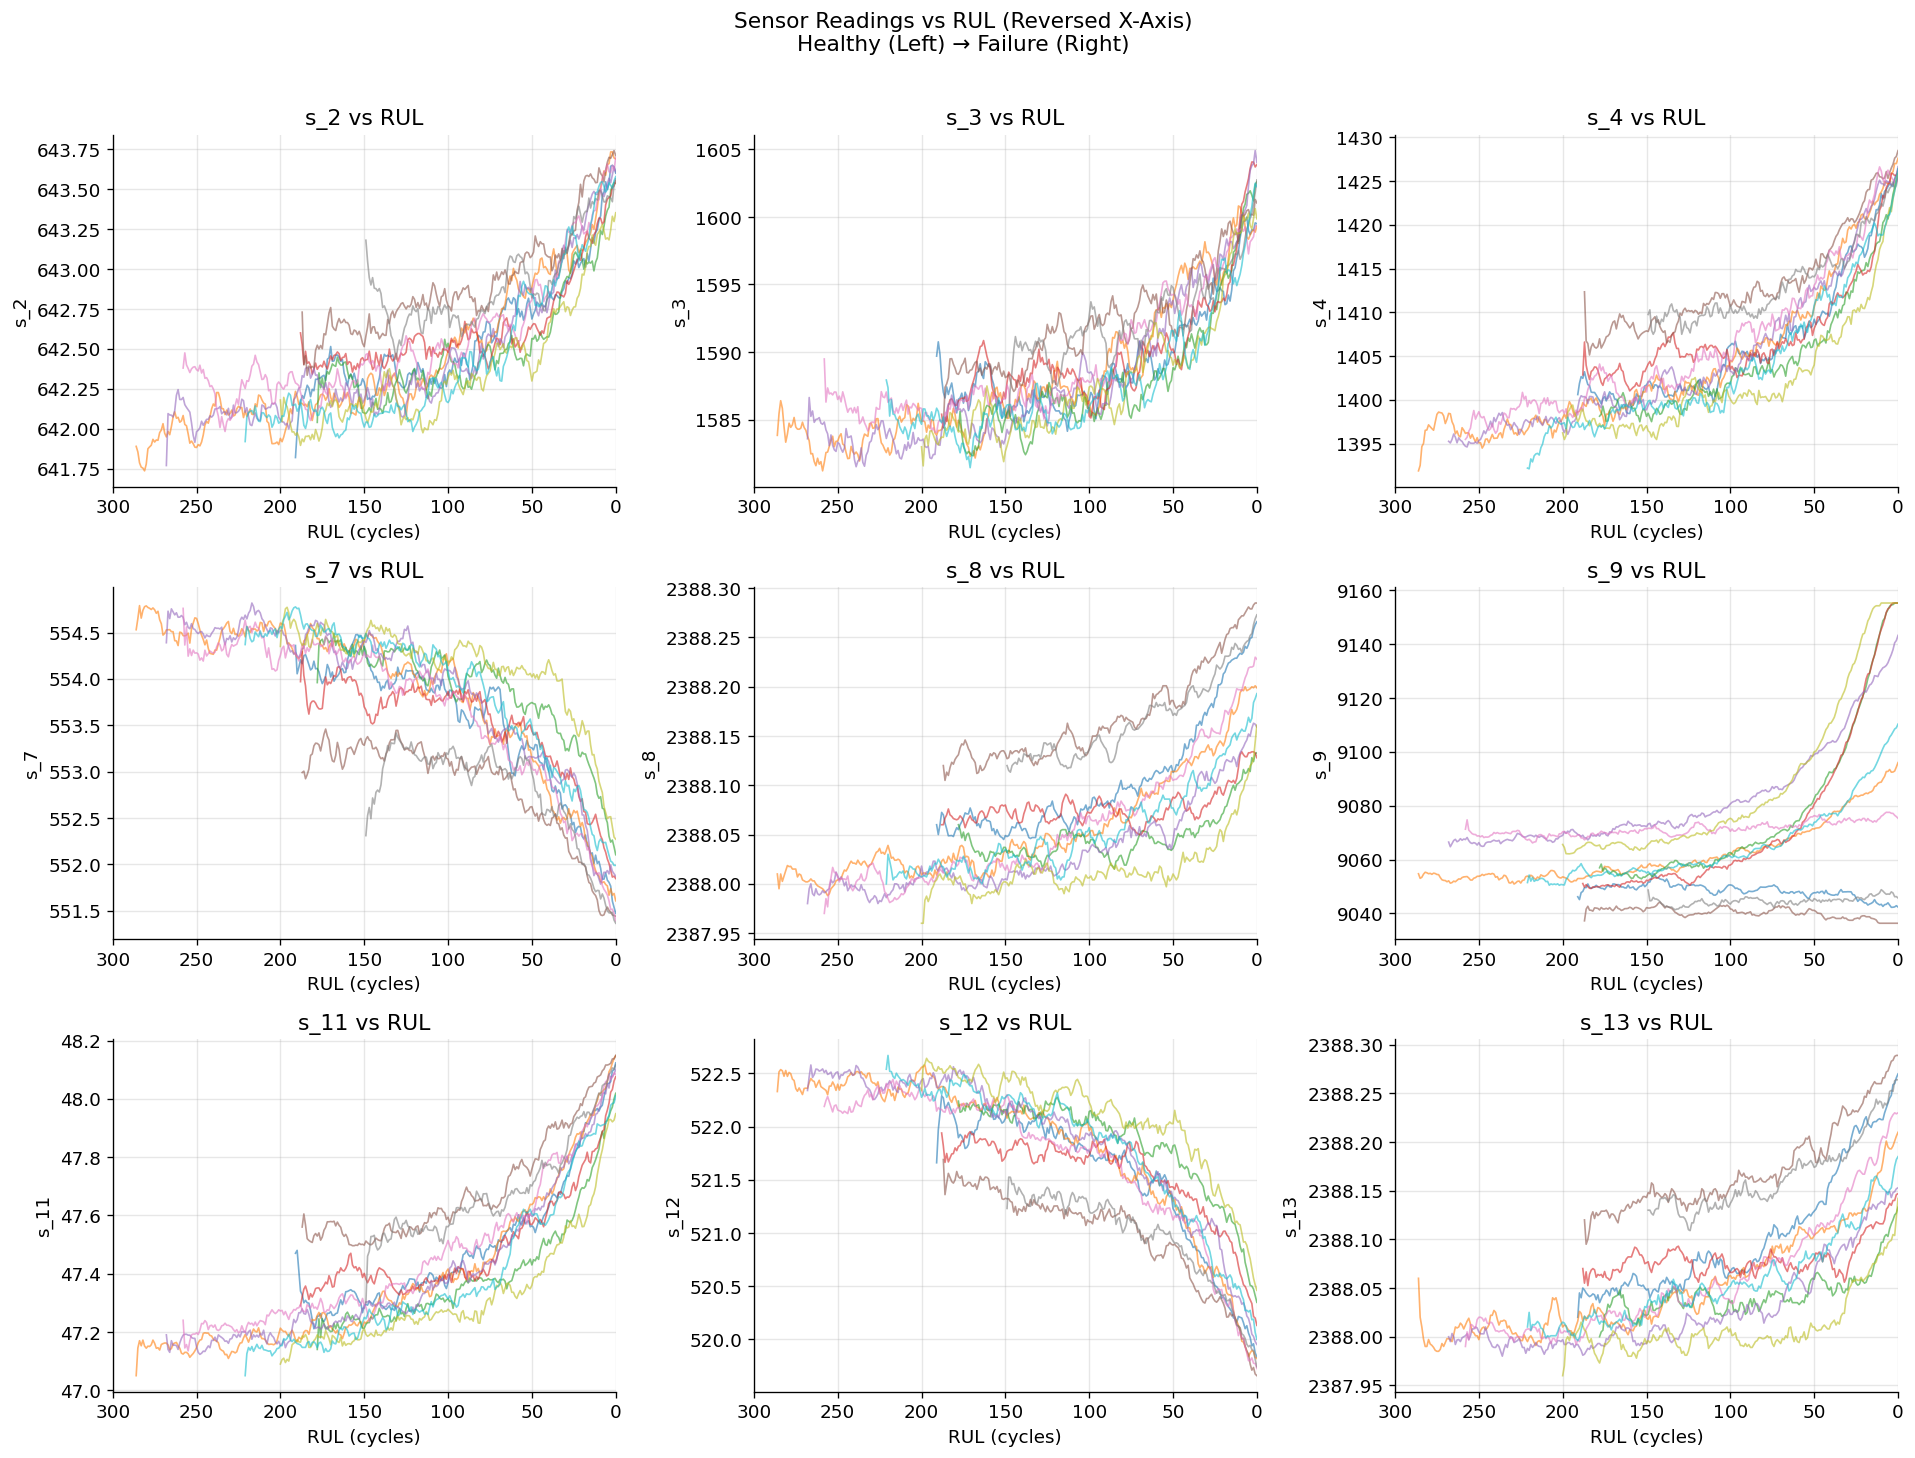

In [8]:
def sensor_trends_analysis(df, sensor_cols):
    """Plot sensor values vs. RUL for a subset of engines."""
    # Calculate RUL for visualization
    rul_temp = df.groupby('unit_number')['time_cycles'].max().reset_index()
    rul_temp.columns = ['unit_number', 'max_cycle']
    df_eda = df.merge(rul_temp, on='unit_number')
    df_eda['RUL'] = df_eda['max_cycle'] - df_eda['time_cycles']
    
    # Plot top sensors
    top_sensors = sensor_cols[:9] # Visualize first 9 sensors
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    
    for i, (sensor, ax) in enumerate(zip(top_sensors, axes.flatten())):
        for unit in df['unit_number'].unique()[:10]: # Plot first 10 engines
            subset = df_eda[df_eda['unit_number'] == unit].sort_values('time_cycles')
            smoothed = subset[sensor].rolling(window=10, min_periods=1).mean()
            ax.plot(subset['RUL'].values, smoothed.values, alpha=0.6, linewidth=1)
        ax.set_xlim(300, 0) # Reverse X-axis (High RUL -> 0 RUL)
        ax.set_xlabel('RUL (cycles)')
        ax.set_ylabel(sensor)
        ax.set_title(f'{sensor} vs RUL')
        
    plt.suptitle('Sensor Readings vs RUL (Reversed X-Axis)\nHealthy (Left) → Failure (Right)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

sensor_trends_analysis(df_train, sensor_cols)

#### Sensor Outlier Analysis
As from above

**High outlier sensors:**  
- `s_9` → 8.17% outliers  
- `s_14` → 7.48% outliers  

*These are significant — more than 5% of the data.*

**Moderate outlier sensors:**  
- `s_6` → 1.97%(removed)
- `s_8` → 1.55%  

**Low outlier sensors:**  
- All the rest < 1%  

> **Important:** Just because a sensor has outliers doesn’t automatically mean you should clip them. Some “outliers” may represent real extreme conditions (e.g., approaching engine failure), which could be highly predictive. Clipping them blindly might lose important signals.


### 3.3 Diagnostic: Correlation Analysis
Check for multicollinearity. If two sensors are highly correlated, they carry redundant information.

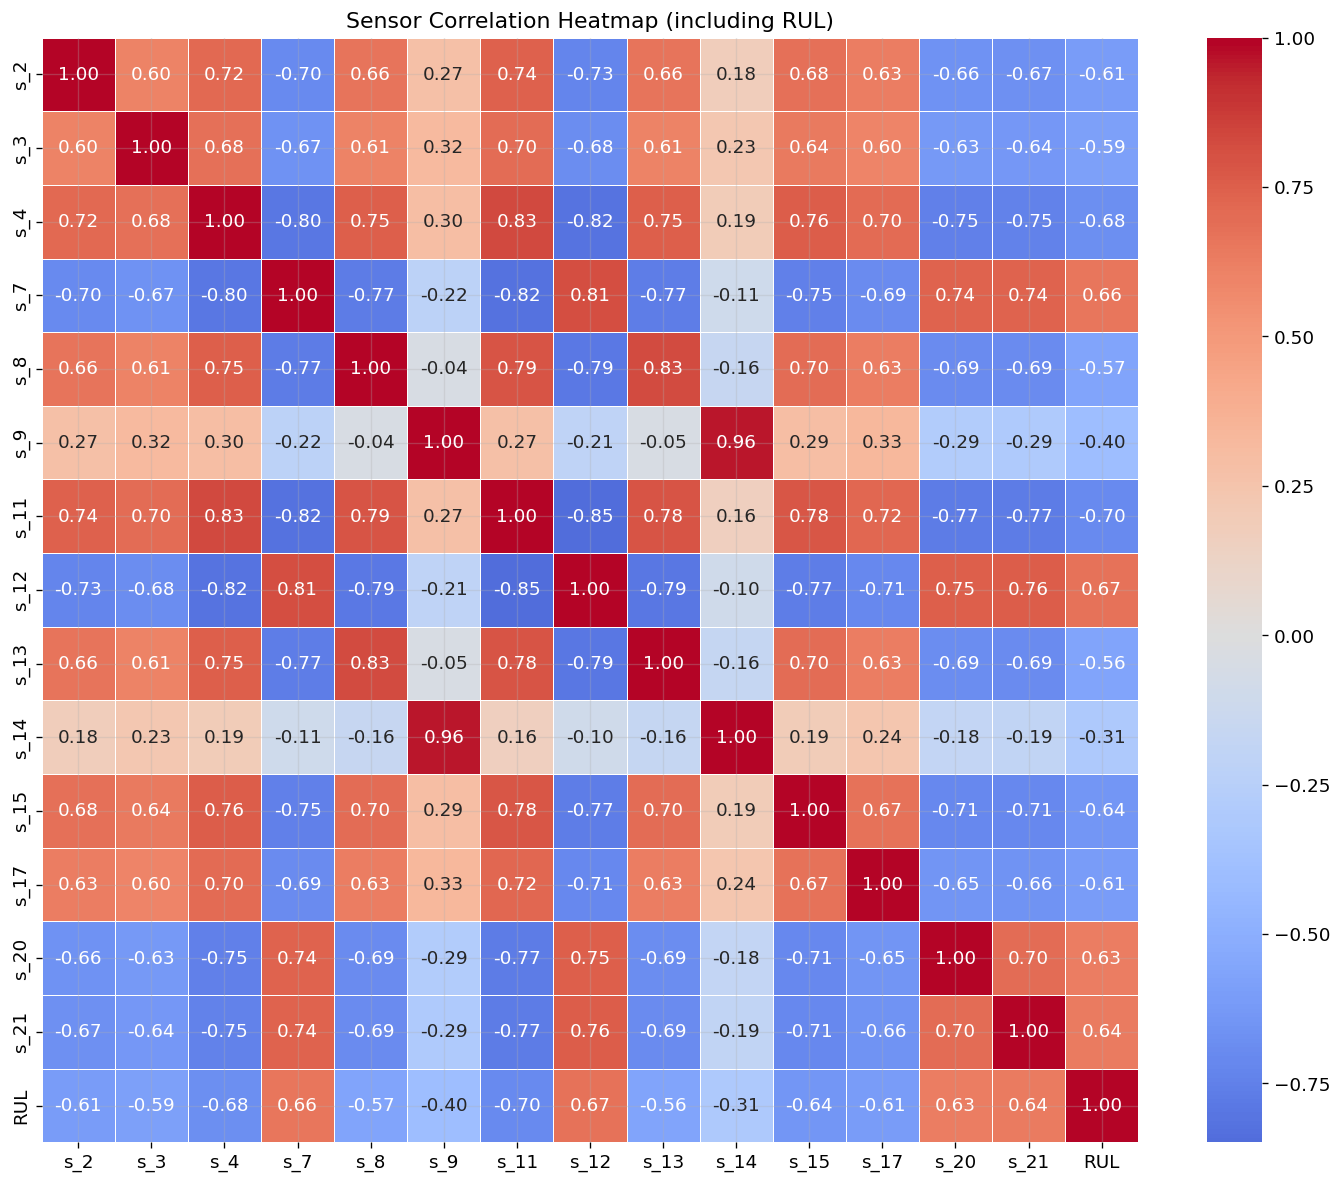

--- Top Correlations with RUL ---
s_11   -0.697527
s_4    -0.680406
s_15   -0.644359
s_2    -0.607851
s_17   -0.607292
s_3    -0.585889
s_8    -0.565334
s_13   -0.564392
s_9    -0.398568
s_14   -0.311738
s_20    0.631037
s_21    0.637153
s_7     0.658647
s_12    0.673323
RUL     1.000000
Name: RUL, dtype: float64


In [9]:
def correlation_analysis(df, sensor_cols):
    """Analyze sensor correlations."""
    rul_temp = df.groupby('unit_number')['time_cycles'].max().reset_index()
    rul_temp.columns = ['unit_number', 'max_cycle']
    df_eda = df.merge(rul_temp, on='unit_number')
    df_eda['RUL'] = df_eda['max_cycle'] - df_eda['time_cycles']
    
    corr = df_eda[sensor_cols + ['RUL']].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Sensor Correlation Heatmap (including RUL)')
    plt.tight_layout()
    plt.show()
    
    return corr['RUL'].sort_values()

rul_corr = correlation_analysis(df_train, sensor_cols)
print("--- Top Correlations with RUL ---")
print(rul_corr)

**Reasoning**: We observe very high correlations (e.g., > 0.9) between certain sensors. This confirms we can use PCA or feature selection to reduce dimensionality.

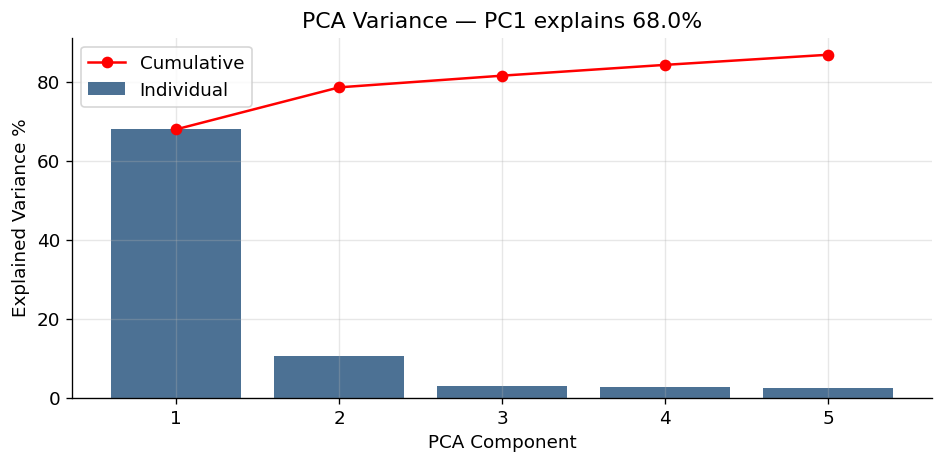

In [10]:
def pca_analysis(df, sensor_cols):
    """Perform PCA to assess global variance."""
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df[sensor_cols])
    
    pca = PCA(n_components=5)
    pca.fit(X_scaled)
    
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(1, 6), explained_variance * 100, color=COLORS[0], alpha=0.8, label='Individual')
    plt.plot(range(1, 6), cumulative_variance * 100, 'r-o', label='Cumulative')
    plt.xlabel('PCA Component')
    plt.ylabel('Explained Variance %')
    plt.title(f'PCA Variance — PC1 explains {explained_variance[0]*100:.1f}%')
    plt.legend()
    plt.tight_layout()
    plt.show()

pca_analysis(df_train, sensor_cols)